> **🤖 AI-coded.** This notebook is part of an **AI-coded extension of [Dynestyx](https://github.com/BasisResearch/dynestyx)** that adds factorial state-space models (fSSMs) — a `dynestyx`-based counterpart to [`cuthberto-carlos`](https://github.com/state-space-models/cuthberto-carlos), built on [`cuthbert`](https://github.com/state-space-models/cuthbert). See the [project README](https://github.com/DanWaxman/dynestyx) for an overview.

# Variational training of factorial models with SVI

The hyperparameters of a factorial state-space model (initial-skill mean/covariance, drift
rate, observation parameters) are usually fit by gradient-MLE or MCMC. This notebook instead
**variationally trains** them: we place priors on *all* hyperparameters and use
**`numpyro.SVI`** with an `AutoMultivariateNormal` guide to learn an approximate posterior —
calibrated uncertainty over the parameters, not just a point estimate.

The likelihood is the factorial **particle-filter** marginal likelihood (it is differentiable
via stop-gradient resampling; the EKF one is not, being forward-only on these rank-deficient
contrast observations). Everything is the **idiomatic dynestyx API** — priors via
`numpyro.sample`, then `with Filter(FactorialPFConfig(...)): dsx.sample(...)` inside a NumPyro
model, fed straight to `numpyro.SVI`. (The model is built with `t0=None` so `dsx.sample`
auto-infers the start time; an explicit scalar `t0` would not survive JIT tracing.)

We demonstrate on two factorial models: a **bivariate-Poisson scoreline** model (World Cup
teams, 2-D attack/defense skill) and a **win/draw/loss outcome** model (English Premier
League, scalar skill).

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpyro
import numpyro.distributions as dist
import optax

jax.config.update("jax_enable_x64", True)

from numpyro.infer import SVI, Trace_ELBO, Predictive
from numpyro.infer.autoguide import AutoMultivariateNormal, AutoLowRankMultivariateNormal
from numpyro.infer.initialization import init_to_value

import dynestyx as dsx
from dynestyx import (
    FactorialDynamicalModel, BivariatePoissonScoreObservation, MatchOutcomeObservation,
    RandomWalkEvolution, Filter, FactorialPFConfig, FactorialEKFConfig,
)
from dynestyx.inference.integrations.cuthbert.factorial_filter import compute_factorial_filter

## 1. Bivariate-Poisson scoreline model (World Cup)

Each of the 48 World Cup teams has a 2-D attack/defense skill following a random walk; match
scorelines are bivariate Poisson. We download the head-to-head history (martj42) at runtime.

In [2]:
URL = "https://raw.githubusercontent.com/martj42/international_results/master/results.csv"
df = pd.read_csv(URL, parse_dates=["date"])
future = df[df["home_score"].isna() & (df["tournament"] == "FIFA World Cup") & (df["date"] >= "2026-06-01")]
wc_teams = sorted(set(future["home_team"]) | set(future["away_team"]))
team_idx = {t: i for i, t in enumerate(wc_teams)}
F = len(wc_teams)
played = df.dropna(subset=["home_score", "away_score"]).copy()
played = played[(played["date"] >= "2015-01-01") & played["home_team"].isin(team_idx)
                & played["away_team"].isin(team_idx)].sort_values("date").reset_index(drop=True)
K = len(played)
days = (played["date"] - played["date"].min()).dt.days.to_numpy().astype(float)
obs_times = jnp.asarray(days / 365.25 + np.arange(K) * 1e-6)
obs_factor_indices = jnp.asarray(np.stack(
    [played["home_team"].map(team_idx).to_numpy(), played["away_team"].map(team_idx).to_numpy()], 1).astype(np.int32))
obs_values = jnp.asarray(np.stack([played["home_score"].to_numpy(), played["away_score"].to_numpy()], 1).astype(np.int32))
MAX_GOALS = int(max(played["home_score"].max(), played["away_score"].max())) + 8
D = 2
print(f"{F} teams, {K} head-to-head scorelines")

48 teams, 1316 head-to-head scorelines


**Model and priors.** Hyperparameters $\theta = \{\mu_0, \Sigma_0, \tau, \alpha, \beta\}$
in an unconstrained pytree ($\Sigma_0 = LL^\top$ via a Cholesky factor, $\tau=\exp(\cdot)$).
`make_model` builds the `FactorialDynamicalModel` with **`t0=None`**. The priors are
weakly-informative.

In [3]:
def natural_params(p):
    cd = jnp.exp(p["log_chol_diag"])
    L = jnp.array([[cd[0], 0.0], [p["chol_offdiag"][0], cd[1]]])
    return p["mu0"], L, jnp.exp(p["log_tau"]), p["alpha"], p["beta"]

def make_model(p):
    mu0, L, tau, alpha, beta = natural_params(p)
    return FactorialDynamicalModel(
        initial_condition=dist.MultivariateNormal(mu0, scale_tril=L),
        state_evolution=RandomWalkEvolution(tau=tau, factor_state_dim=D),
        observation_model=BivariatePoissonScoreObservation(alpha=alpha, beta=beta, factor_state_dim=D, max_goals=MAX_GOALS),
        num_factors=F, num_local_factors=2, t0=None)   # t0=None: dsx.sample auto-infers t0 under tracing

PRIORS = {
    "mu0":           dist.Normal(0.0, 1.0).expand([2]).to_event(1),
    "log_chol_diag": dist.Normal(jnp.log(0.5), 0.7).expand([2]).to_event(1),
    "chol_offdiag":  dist.Normal(0.0, 0.5).expand([1]).to_event(1),
    "log_tau":       dist.Normal(jnp.log(0.4), 0.7).expand([2]).to_event(1),
    "alpha":         dist.Normal(0.25, 0.5),
    "beta":          dist.Normal(-1.5, 1.0),
}

**MLE warm-start.** SVI converges much faster (and more stably) if the guide is
initialised at the maximum-likelihood point, so we first take ~150 Adam steps on the
(differentiable, common-random-numbers) PF marginal log-likelihood. This is the one place we
use `compute_factorial_filter` directly — a bare differentiable scalar objective, not a
probabilistic model.

In [4]:
OPT_KEY = jax.random.PRNGKey(0)
def neg_loglik(p):
    ll, *_ = compute_factorial_filter(make_model(p), FactorialPFConfig(n_particles=300), OPT_KEY,
                                      obs_times=obs_times, obs_values=obs_values, obs_factor_indices=obs_factor_indices)
    return -ll / K

vg = jax.jit(jax.value_and_grad(neg_loglik))
mle = {"mu0": jnp.zeros(2), "log_chol_diag": jnp.log(jnp.array([0.5, 0.5])), "chol_offdiag": jnp.zeros(1),
       "log_tau": jnp.log(jnp.array([0.4, 0.4])), "alpha": jnp.array(0.25), "beta": jnp.array(-1.5)}
opt = optax.adam(0.05); st = opt.init(mle)
for _ in range(150):
    loss, g = vg(mle); u, st = opt.update(g, st); mle = optax.apply_updates(mle, u)
print(f"MLE neg-loglik/match = {float(loss):.4f}")

MLE neg-loglik/match = 2.8865


**SVI.** The idiomatic factorial model under SVI: sample the hyperparameters from the
priors, then `with Filter(FactorialPFConfig): dsx.sample(...)`. We fit an
`AutoMultivariateNormal` guide (well-sized for these ~8 parameters), initialised at the MLE.

In [5]:
def svi_model():
    p = {name: numpyro.sample(name, prior) for name, prior in PRIORS.items()}
    with Filter(filter_config=FactorialPFConfig(n_particles=300, crn_seed=jax.random.PRNGKey(0))):
        dsx.sample("score", make_model(p), obs_times=obs_times, obs_values=obs_values, obs_factor_indices=obs_factor_indices)

guide = AutoMultivariateNormal(svi_model, init_loc_fn=init_to_value(values=mle))
svi = SVI(svi_model, guide, optax.adam(0.02), loss=Trace_ELBO())
svi_result = svi.run(jax.random.PRNGKey(1), 400, progress_bar=False)
post = guide.sample_posterior(jax.random.PRNGKey(2), svi_result.params, sample_shape=(500,))
print(f"ELBO loss: {float(svi_result.losses[0]):.1f} -> {float(svi_result.losses[-1]):.1f}")

ELBO loss: 3838.2 -> 3818.8


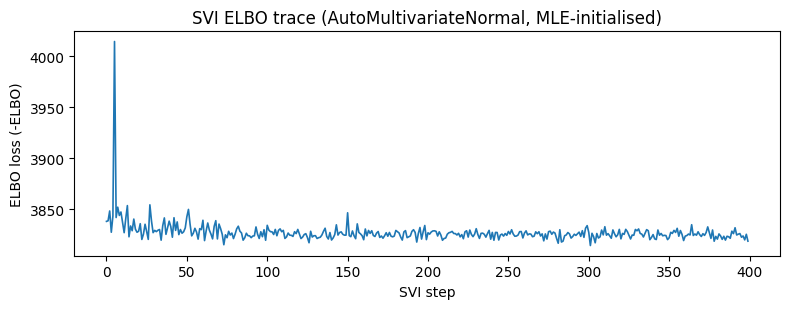

In [6]:
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(np.asarray(svi_result.losses), lw=1.2)
ax.set_xlabel("SVI step"); ax.set_ylabel("ELBO loss (-ELBO)")
ax.set_title("SVI ELBO trace (AutoMultivariateNormal, MLE-initialised)")
plt.tight_layout(); plt.show()

In [7]:
# Posterior summary (mean +/- std) in natural-parameter space, vs the MLE point estimate.
def summarize(samples):
    tau = jnp.exp(samples["log_tau"]); cd = jnp.exp(samples["log_chol_diag"])
    sig_diag = cd ** 2  # diagonal of Sigma_0 (ignoring the off-diagonal for display)
    return {
        "alpha": samples["alpha"], "beta": samples["beta"],
        "tau_att": tau[:, 0], "tau_def": tau[:, 1],
        "sigma0_att": sig_diag[:, 0], "sigma0_def": sig_diag[:, 1],
    }
ps = summarize(post)
mu0_m, L_m, tau_m, alpha_m, beta_m = natural_params(mle)
sig_m = np.diag(np.asarray(L_m @ L_m.T))
mle_vals = {"alpha": float(alpha_m), "beta": float(beta_m), "tau_att": float(tau_m[0]), "tau_def": float(tau_m[1]),
            "sigma0_att": float(sig_m[0]), "sigma0_def": float(sig_m[1])}
pd.DataFrame({
    "parameter": list(ps.keys()),
    "SVI posterior mean": [float(v.mean()) for v in ps.values()],
    "SVI posterior std":  [float(v.std()) for v in ps.values()],
    "gradient-MLE":       [mle_vals[k] for k in ps],
}).round(3)

,parameter,SVI posterior mean,SVI posterior std,gradient-MLE
0,alpha,0.194,0.077,0.209
1,beta,-2.652,0.404,-2.939
2,tau_att,0.058,0.015,0.047
3,tau_def,0.072,0.016,0.063
4,sigma0_att,0.107,0.030,0.093
5,sigma0_def,0.010,0.006,0.045


The variational posterior means track the MLE, now **with uncertainty**. (The baseline
$\alpha$ and $\mu_0$ share a flat identifiability direction — a match constrains only
attack-minus-opponent-defense contrasts — so their marginals are weakly pinned by the priors;
predictions, which depend only on contrasts, are unaffected.) A low-rank guide gives a
near-identical fit here:

In [8]:
guide_lr = AutoLowRankMultivariateNormal(svi_model, rank=3, init_loc_fn=init_to_value(values=mle))
svi_lr = SVI(svi_model, guide_lr, optax.adam(0.02), loss=Trace_ELBO())
res_lr = svi_lr.run(jax.random.PRNGKey(3), 400, progress_bar=False)
post_lr = guide_lr.sample_posterior(jax.random.PRNGKey(4), res_lr.params, sample_shape=(500,))
print(f"AutoMVN     final ELBO loss {float(svi_result.losses[-1]):.1f}   alpha {float(post['alpha'].mean()):+.3f}")
print(f"AutoLowRank final ELBO loss {float(res_lr.losses[-1]):.1f}   alpha {float(post_lr['alpha'].mean()):+.3f}")

AutoMVN     final ELBO loss 3818.8   alpha +0.194
AutoLowRank final ELBO loss 3833.2   alpha +0.217


**Attack/defense ratings at the posterior mean** — computed the **idiomatic** way:
run the (deterministic) EKF via `with Filter(...): dsx.sample(...)` and read the recorded
`score_filtered_states_mean` site through `numpyro.infer.Predictive`.

In [9]:
post_mean = {k: post[k].mean(0) for k in post}
def rating_program():
    with Filter(filter_config=FactorialEKFConfig(record_filtered_states_mean=True)):
        dsx.sample("score", make_model(post_mean), obs_times=obs_times, obs_values=obs_values, obs_factor_indices=obs_factor_indices)
pr = Predictive(rating_program, num_samples=1)(jax.random.PRNGKey(0))
skills = np.asarray(pr["score_filtered_states_mean"][0])  # (F, 2): attack, defense
overall = skills[:, 0] + skills[:, 1]
order = np.argsort(-overall)[:12]
pd.DataFrame({"team": [wc_teams[i] for i in order],
              "attack": skills[order, 0].round(2), "defense": skills[order, 1].round(2),
              "overall": overall[order].round(2)}).reset_index(drop=True)

,team,attack,defense,overall
0,Croatia,0.11,0.19,0.30
1,Brazil,0.10,0.19,0.29
2,South Korea,0.08,0.18,0.26
3,United States,0.07,0.17,0.25
4,Argentina,0.04,0.16,0.19
5,Belgium,0.06,0.10,0.17
6,Japan,0.03,0.14,0.16
7,Iran,-0.01,0.14,0.13
8,Sweden,0.02,0.09,0.10
9,Uruguay,-0.01,0.12,0.10


## 2. Win/draw/loss outcome model (English Premier League)

A scalar-skill model: each team's strength follows a random walk, and the match outcome is a
sigmoidal function of the skill difference with a draw margin $\varepsilon$ (Duffield et al.'s
Elo–Davidson SSM). Hyperparameters $\{\sigma_0^2, \tau, \varepsilon\}$, log-parameterised. We
download EPL 2018–2022 and variationally train them, then compare to Duffield et al.'s fitted
values and evaluate the held-out NLL.

In [10]:
import io, time, urllib.request
def fetch_csv(url, tries=5):
    for t in range(tries):
        try:
            req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
            with urllib.request.urlopen(req, timeout=90) as r:
                return io.BytesIO(r.read())
        except Exception:
            if t == tries - 1: raise
            time.sleep(4)
ORIGIN = pd.to_datetime("2018-07-30")
cols = ["Date", "HomeTeam", "AwayTeam", "FTHG", "FTAG"]
frames = [pd.read_csv(fetch_csv(f"https://www.football-data.co.uk/mmz4281/{str(y)[-2:]}{str(y+1)[-2:]}/E0.csv"))[cols]
          for y in range(2018, 2022)]
epl = pd.concat(frames, ignore_index=True).dropna()
epl["T"] = pd.to_datetime(epl["Date"], dayfirst=True)
epl["D"] = (epl["T"] - ORIGIN).dt.days
teams = sorted(pd.unique(pd.concat([epl["HomeTeam"], epl["AwayTeam"]])))
tix = {t: i for i, t in enumerate(teams)}
epl = epl[(epl["T"] > ORIGIN) & (epl["T"] <= pd.to_datetime("2022-07-01"))].sort_values("D").reset_index(drop=True)
e_times = jnp.asarray(epl["D"].to_numpy().astype(float) + np.arange(len(epl)) * 1e-6)  # ramp breaks same-day ties (dsx.sample needs strictly-increasing times)
e_idx = jnp.asarray(epl[["HomeTeam", "AwayTeam"]].apply(lambda c: c.map(tix)).to_numpy().astype(np.int32))
hg, ag = epl["FTHG"].to_numpy(), epl["FTAG"].to_numpy()
e_out = jnp.asarray(np.where(hg > ag, 1, np.where(hg < ag, 2, 0)))
n_teams = int(e_idx.max()) + 1
e_K = len(e_out)
e_test_start = int(np.where(np.asarray(e_times) > 365 * 3)[0][0])
print(f"EPL: {e_K} matches, {n_teams} teams, train {e_test_start} / test {e_K - e_test_start}")

EPL: 1520 matches, 26 teams, train 1140 / test 380


In [11]:
def outcome_model(p):
    return FactorialDynamicalModel(
        initial_condition=dist.MultivariateNormal(jnp.zeros(1), jnp.exp(p["log_init_var"]) * jnp.eye(1)),
        state_evolution=RandomWalkEvolution(tau=jnp.exp(p["log_tau"]), factor_state_dim=1),
        observation_model=MatchOutcomeObservation(draw_margin=jnp.exp(p["log_eps"]), scale=1.0, factor_state_dim=1),
        num_factors=n_teams, num_local_factors=2, t0=None)

E_PRIORS = {
    "log_init_var": dist.Normal(jnp.log(0.15), 0.7),
    "log_tau":      dist.Normal(jnp.log(0.005), 1.0),
    "log_eps":      dist.Normal(jnp.log(0.4), 0.7),
}
def e_svi_model():
    p = {name: numpyro.sample(name, prior) for name, prior in E_PRIORS.items()}
    with Filter(filter_config=FactorialPFConfig(n_particles=400, crn_seed=jax.random.PRNGKey(0))):
        dsx.sample("skill", outcome_model(p), obs_times=e_times, obs_values=e_out, obs_factor_indices=e_idx)

e_init = {"log_init_var": jnp.log(jnp.array(0.13)), "log_tau": jnp.log(jnp.array(0.005)), "log_eps": jnp.log(jnp.array(0.45))}
e_guide = AutoMultivariateNormal(e_svi_model, init_loc_fn=init_to_value(values=e_init))
e_svi = SVI(e_svi_model, e_guide, optax.adam(0.03), loss=Trace_ELBO())
e_res = e_svi.run(jax.random.PRNGKey(5), 300, progress_bar=False)
e_post = e_guide.sample_posterior(jax.random.PRNGKey(6), e_res.params, sample_shape=(500,))
print(f"ELBO loss: {float(e_res.losses[0]):.1f} -> {float(e_res.losses[-1]):.1f}")

ELBO loss: 1513.7 -> 1496.5


In [12]:
# Posterior vs Duffield et al.'s EM-fitted EPL outcome parameters.
pd.DataFrame({
    "parameter": ["init_var", "tau", "epsilon"],
    "SVI posterior mean": [float(jnp.exp(e_post["log_init_var"]).mean()),
                           float(jnp.exp(e_post["log_tau"]).mean()),
                           float(jnp.exp(e_post["log_eps"]).mean())],
    "SVI posterior std":  [float(jnp.exp(e_post["log_init_var"]).std()),
                           float(jnp.exp(e_post["log_tau"]).std()),
                           float(jnp.exp(e_post["log_eps"]).std())],
    "Duffield (EM)":      [0.13117045, 0.00100004, 0.4741553],
}).round(4)

,parameter,SVI posterior mean,SVI posterior std,Duffield (EM)
0,init_var,0.4147,0.1023,0.1312
1,tau,0.0038,0.0022,0.0010
2,epsilon,0.5345,0.0266,0.4742


**Held-out predictive performance** at the posterior mean, via the existing
`dynestyx.contrib` one-step-ahead helper (paper Table 2: EPL outcome **test** NLL ≈ 0.965 (their ExKF), 0.961 (best); the 0.988 sometimes quoted is the *train* NLL):

In [13]:
from dynestyx.contrib import outcome_predictive_probs, split_nll
e_mean = {k: e_post[k].mean(0) for k in e_post}
pp = outcome_predictive_probs(outcome_model(e_mean), FactorialPFConfig(n_particles=1000),
                              obs_times=e_times, obs_values=e_out, obs_factor_indices=e_idx,
                              key=jax.random.PRNGKey(7))
nll = split_nll(pp, e_out, e_test_start)
print(f"held-out test NLL at the SVI posterior mean: {nll['test_nll']:.3f}  (Duffield test 0.965 ExKF, 0.961 best)")

held-out test NLL at the SVI posterior mean: 0.961  (Duffield test 0.965 ExKF, 0.961 best)


## 3. Discussion

- **Variational training works for factorial SSMs** through the idiomatic `dsx.sample` API: put
  priors on the hyperparameters, wrap the model in `with Filter(FactorialPFConfig): dsx.sample`,
  and hand it to `numpyro.SVI` with an `AutoMultivariateNormal` guide. No special machinery.
- **PF, not EKF:** the particle-filter marginal likelihood is differentiable (stop-gradient
  resampling), so the ELBO has gradients; the EKF likelihood is forward-only here.
- **Uncertainty for free:** unlike a point MLE, SVI returns a posterior — useful for propagating
  parameter uncertainty into forecasts. `AutoMultivariateNormal` is well-sized for these low-dim
  parameter sets; `AutoLowRankMultivariateNormal` scales to larger ones.
- An MLE warm-start (`init_to_value`) makes SVI converge in a few hundred steps. `make_model` uses
  `t0=None` so `dsx.sample` auto-infers the start time under JIT tracing.